<a href="https://colab.research.google.com/github/sarvesh35ss/DAA1/blob/main/DAA2a.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TEXT LENGTH = 10000

STRING MATCHING COMPARISON RESULTS



,Pattern Length,Naive Comparisons,KMP Comparisons,Rabin-Karp Comparisons
0,5,10373,10364,102
1,10,10414,10409,92
2,20,10370,10370,91
3,50,10371,10410,104



PATTERNS USED:
Length 5: yxsta
Length 10: zyppcoyhba
Length 20: nqlhwzabuvnwrtobtsll
Length 50: dlxzjflbgpftxuozasvbdebjrghpmdbgomtjxfsyuhqngsnbxs


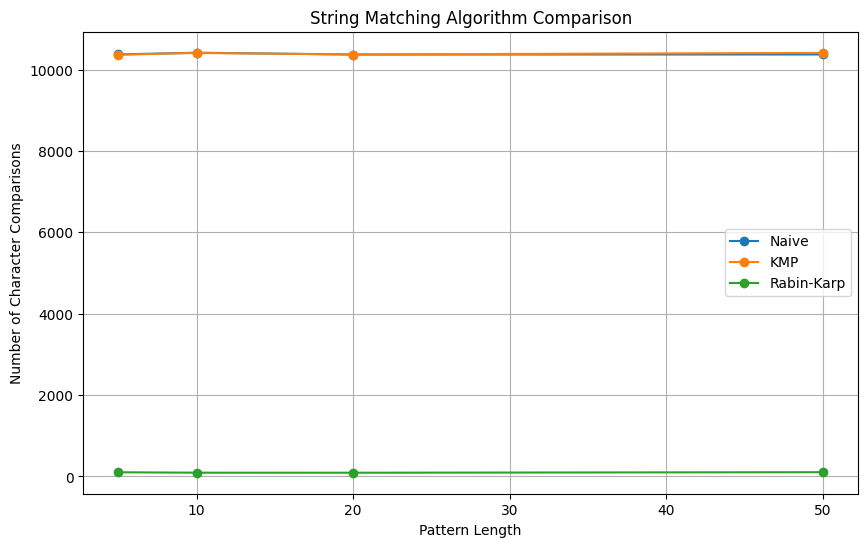

In [5]:
# ============================================
# STRING MATCHING ALGORITHMS
# Naive, KMP and Rabin-Karp
# ============================================

import random
import string
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------
# 1. Generate Text of 10,000 Characters
# ------------------------------------------------

random.seed(42)

n = 10000

text = ''.join(random.choices(string.ascii_lowercase, k=n))

# Pattern lengths to test
pattern_lengths = [5, 10, 20, 50]


# ------------------------------------------------
# 2. Naive String Matching
# ------------------------------------------------

def naive_search(text, pattern):
    n = len(text)
    m = len(pattern)

    comparisons = 0
    positions = []

    for i in range(n - m + 1):
        j = 0

        while j < m:
            comparisons += 1

            if text[i + j] != pattern[j]:
                break

            j += 1

        if j == m:
            positions.append(i)

    return positions, comparisons


# ------------------------------------------------
# 3. KMP String Matching
# ------------------------------------------------

def compute_lps(pattern):
    m = len(pattern)

    lps = [0] * m

    length = 0
    i = 1

    while i < m:

        if pattern[i] == pattern[length]:
            length += 1
            lps[i] = length
            i += 1

        else:
            if length != 0:
                length = lps[length - 1]
            else:
                lps[i] = 0
                i += 1

    return lps


def kmp_search(text, pattern):
    n = len(text)
    m = len(pattern)

    lps = compute_lps(pattern)

    i = 0
    j = 0

    comparisons = 0
    positions = []

    while i < n:

        comparisons += 1

        if text[i] == pattern[j]:
            i += 1
            j += 1

            if j == m:
                positions.append(i - j)
                j = lps[j - 1]

        else:
            if j != 0:
                j = lps[j - 1]
            else:
                i += 1

    return positions, comparisons


# ------------------------------------------------
# 4. Rabin-Karp String Matching
# ------------------------------------------------

def rabin_karp_search(text, pattern):

    n = len(text)
    m = len(pattern)

    if m > n:
        return [], 0

    # Prime number
    prime = 101

    # Base
    d = 256

    pattern_hash = 0
    text_hash = 0

    h = 1

    comparisons = 0
    positions = []

    # Calculate h = d^(m-1) % prime
    for _ in range(m - 1):
        h = (h * d) % prime

    # Calculate initial hash values
    for i in range(m):
        pattern_hash = (d * pattern_hash + ord(pattern[i])) % prime
        text_hash = (d * text_hash + ord(text[i])) % prime

    # Slide pattern over text
    for i in range(n - m + 1):

        # If hash values match, compare characters
        if pattern_hash == text_hash:

            j = 0

            while j < m:
                comparisons += 1

                if text[i + j] != pattern[j]:
                    break

                j += 1

            if j == m:
                positions.append(i)

        # Calculate hash for next window
        if i < n - m:

            text_hash = (
                d * (text_hash - ord(text[i]) * h)
                + ord(text[i + m])
            ) % prime

            if text_hash < 0:
                text_hash += prime

    return positions, comparisons


# ------------------------------------------------
# 5. Generate Patterns
# ------------------------------------------------

# We create patterns that are NOT likely to occur
# in the random text so that comparison behavior
# can be observed clearly.

patterns = {}

for length in pattern_lengths:
    patterns[length] = ''.join(
        random.choices(string.ascii_lowercase, k=length)
    )


# ------------------------------------------------
# 6. Run All Three Algorithms
# ------------------------------------------------

results = []

for length in pattern_lengths:

    pattern = patterns[length]

    # Naive
    _, naive_comparisons = naive_search(text, pattern)

    # KMP
    _, kmp_comparisons = kmp_search(text, pattern)

    # Rabin-Karp
    _, rk_comparisons = rabin_karp_search(text, pattern)

    results.append({
        "Pattern Length": length,
        "Naive Comparisons": naive_comparisons,
        "KMP Comparisons": kmp_comparisons,
        "Rabin-Karp Comparisons": rk_comparisons
    })


# ------------------------------------------------
# 7. Display Results
# ------------------------------------------------

df = pd.DataFrame(results)

print("TEXT LENGTH =", n)
print("\nSTRING MATCHING COMPARISON RESULTS\n")

display(df)


# ------------------------------------------------
# 8. Display Patterns Used
# ------------------------------------------------

print("\nPATTERNS USED:")

for length, pattern in patterns.items():
    print(f"Length {length}: {pattern}")


# ------------------------------------------------
# 9. Plot Comparison Graph
# ------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    df["Pattern Length"],
    df["Naive Comparisons"],
    marker='o',
    label="Naive"
)

plt.plot(
    df["Pattern Length"],
    df["KMP Comparisons"],
    marker='o',
    label="KMP"
)

plt.plot(
    df["Pattern Length"],
    df["Rabin-Karp Comparisons"],
    marker='o',
    label="Rabin-Karp"
)

plt.xlabel("Pattern Length")
plt.ylabel("Number of Character Comparisons")

plt.title("String Matching Algorithm Comparison")

plt.legend()
plt.grid(True)

plt.show()